**Decision Tree and Regression: Working Principle**

- Decision trees are powerful ML models effectively used in both classification and regression problems. When used for regression problems, the basic working principle of a decision tree is based on predicting the values of **continuous variables** within the dataset.
- This process occurs by splitting the dataset into homogeneous subsets, minimizing the variance of each subset.

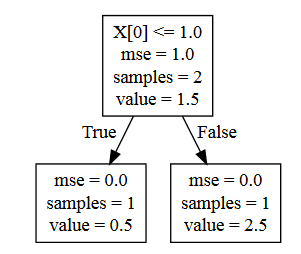


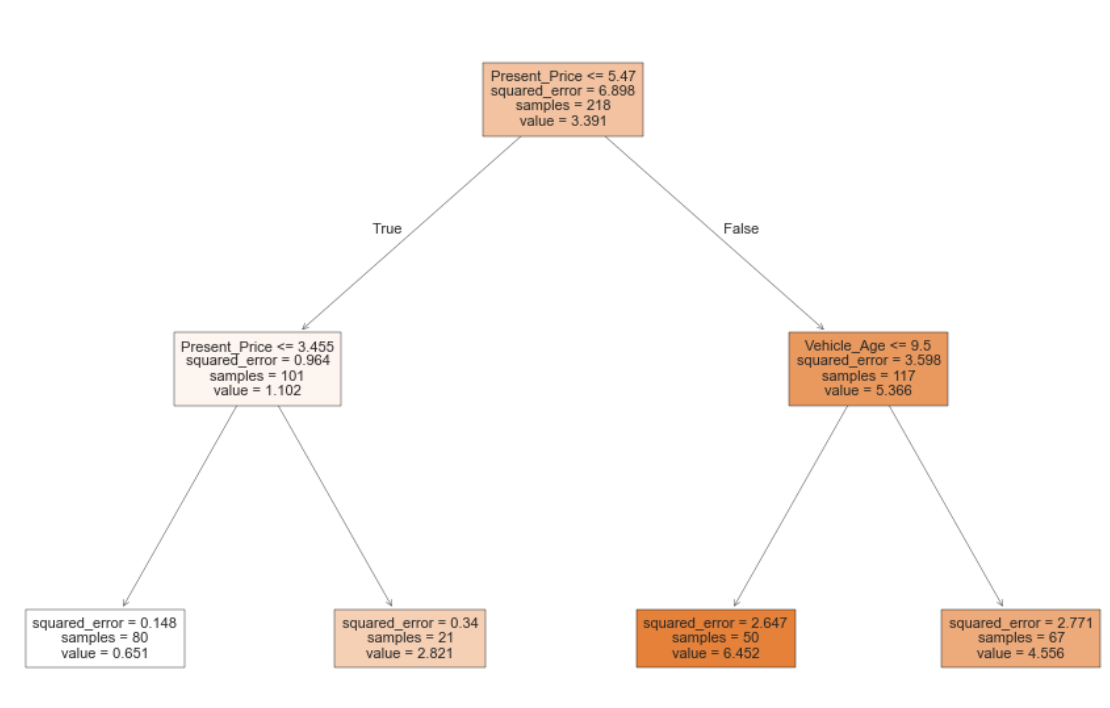


- TD regressor **give** us a **numerical value** at the end of the analysis. 

**Variance and Mean-Based Approach**

**Difference**
- In regression problems, decision trees do not rely on purity measures like entropy or Gini, which are commonly used in classification problems.
- Instead, tree structures use statistical methods such as variance minimization to improve the predictions of continuous variables within the dataset.

**Use of Variance**
- The Decision Tree Regressor is designed to minimize the variance of the resulting subsets after each split of the dataset.
- Variance is a measure of how much the values in a dataset differ from the mean of the dataset.
- By minimizing variance, a decision tree groups data points with similar values together, allowing for more consistent predictions.

**Prediction Method**

- In a Decision Tree Regressor, the average of the data points covered by a branch or node is used as the predicted value for that branch or node.
- This method provides a generalized prediction for a region by taking the average of all data points' values within that region.

**Advanced Information and Improvements**

- **Pruning:** Pruning techniques can be used to reduce the tendency of decision trees to overfit. Pruning enhances the model's generalization ability by trimming unnecessary branches of the tree.
- **Cross Validation:** Cross-validation techniques can be applied to evaluate the model's performance and minimize the risk of overfitting. This helps the model make more robust and reliable predictions by testing its performance on different data subsets.
- **Feature Importance:** Decision trees are useful for identifying which features have the most impact on predictions. This is an important tool for understanding which features have the strongest influence on the target variable.

A Decision Tree Regressor, based on these principles and techniques, can model complex relationships and patterns in datasets and effectively predict the values of continuous variables.

These models stand out as powerful and flexible prediction tools, especially in cases where the relationships between different features are not linear.

**Differences between Regression and Classification**

- **Purpose:** The goal of regression is to **predict the value of a continuous target variable**, such as estimating the price of a house or the fuel consumption of a vehicle. Classification, on the other hand, involves categorizing observations into predefined categories, such as determining whether an email is spam or diagnosing a disease.
- **Target Variable:** In regression, the **target variable takes a continuous value**, while in classification, it takes a categorical (labeled) value.
- **Evaluation Metrics:** Common evaluation metrics for regression models include **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)**, **Root Mean Square Error (RMSE)** and **R-squared**. For classification models, metrics such as accuracy, precision, recall, and F1 score are used.
- **Model Approaches:** While decision trees use **variance minimization** in regression problems, they typically use purity measures like entropy or Gini in classification problems.

# Exploratory Data Analysis

- **Car_Name**: The name or model of the car.
- **Year**: The year of manufacture of the car.
- **Selling_Price**: The selling price of the car.
- **Present_Price**: The current showroom price of the car.
- **Kms_Driven**: The total kilometers driven by the car up to the point of sale.
- **Fuel_Type**: This column would contain categories such as:
  - **Petrol**: Cars that run on petrol fuel.
  - **Diesel**: Cars that use diesel fuel.
  - **CNG**: Cars that are powered by compressed natural gas.

- **Seller_Type**: This column would indicate the type of seller offering the car, which could be:
  - **Dealer**: A business that sells cars as part of its commercial operations.
  - **Individual**: A private individual selling a personal vehicle.

- **Transmission**: This refers to the gearbox system of the car, with common types being:
  - **Manual**: Cars where the driver manually shifts gears.
  - **Automatic**: Cars where the gear shifting process is automated.

- **Owner**: This would typically be a numeric column indicating the number of previous owners of the car, but if it is categorical, it might have entries such as:
  - **First Owner**: Indicates the car is being sold by its original owner.
  - **Second Owner**: Indicates the car has had one previous owner before the current seller.
  - **Third Owner**, and so on.
  
This data set is for estimating the selling price of a car based on its features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf  # !pip install cufflinks

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

init_notebook_mode(connected=True)
cf.go_offline()

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.3f}'.format
plt.rcParams["figure.figsize"] = (9, 5)

import warnings

warnings.filterwarnings('ignore')

In [2]:
# If you get an error related "cufflinks"
#!pip install cufflinks

In [3]:
df0 = pd.read_csv("car_dataset.csv")

df = df0.copy()

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.350,5.590,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.750,9.540,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.250,9.850,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.850,4.150,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.600,6.870,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.000,2013.628,2.892,2003.000,2012.000,2014.000,2016.000,2018.000
Selling_Price,301.000,4.661,5.083,0.100,0.900,3.600,6.000,35.000
Present_Price,301.000,7.628,8.644,0.320,1.200,6.400,9.900,92.600
Kms_Driven,301.000,36947.206,38886.884,500.000,15000.000,32000.000,48767.000,500000.000
Owner,301.000,0.043,0.248,0.000,0.000,0.000,0.000,3.000


In [9]:
import plotly.express as px

numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

fig = px.imshow(corr_matrix, text_auto='.2f', aspect="auto", color_continuous_scale='RdBu_r')
fig.show()

<Axes: >

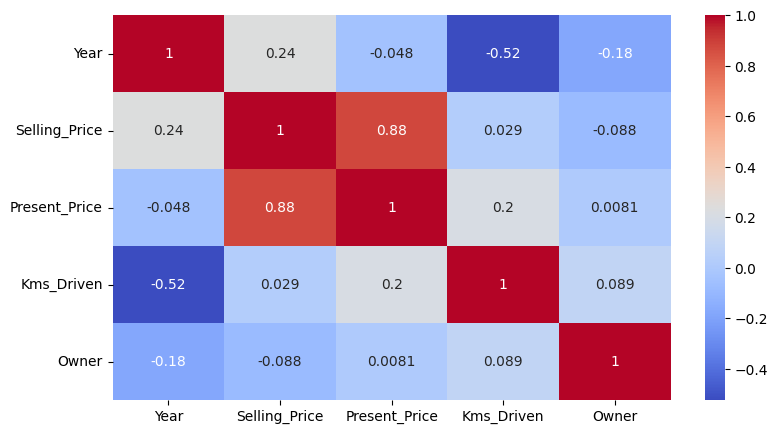

In [10]:
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

# # sns.heatmap(df.corr(), annot = True)

In [11]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.350,5.590,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.750,9.540,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.250,9.850,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.850,4.150,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.600,6.870,42450,Diesel,Dealer,Manual,0


## Feature Engineering

In [12]:
df["Vehicle_Age"] = 2025 - df.Year

# We are converting the vehicle manufacturing year in our dataset into the Vehicle_Age feature

In [13]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,ritz,2014,3.350,5.590,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.750,9.540,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.250,9.850,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.850,4.150,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.600,6.870,42450,Diesel,Dealer,Manual,0,11


In [14]:
def unique_values(df, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [15]:
cat_features = df.select_dtypes(include='object').columns
unique_values(df, cat_features)

# We see how many unique observations the categorical features consist of. The number of unique categorical observations 
# for car_name is very high compared to the total number of observations in our dataset.

Column: Car_Name
------------------------------
Unique Values (98): ['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS 

In [16]:
df.drop(columns=["Car_Name", "Year"], inplace=True)

# Even though I have 301 observations, there are 98 unique car/motorcycle brands in car_name. 
# Applying an ordinal encoder to this feature to convert it into numeric data will not be a meaningful approach 
# because decision tree models tend to assign more importance to high cardinality categorical features 
# (features with many unique categorical observations). This causes these features to become more prominent in 
# feature importance. Additionally, there are only 1-2 instances of most brands and models. Naturally, since they 
# do not contribute to the training, we are removing this feature. Since we have converted Year, 
# which is the vehicle's manufacturing year, into the Vehicle_Age feature, we are also removing the Year 
# feature along with car_name.

In [17]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,3.350,5.590,27000,Petrol,Dealer,Manual,0,11
1,4.750,9.540,43000,Diesel,Dealer,Manual,0,12
2,7.250,9.850,6900,Petrol,Dealer,Manual,0,8
3,2.850,4.150,5200,Petrol,Dealer,Manual,0,14
4,4.600,6.870,42450,Diesel,Dealer,Manual,0,11


<Figure size 1200x600 with 0 Axes>

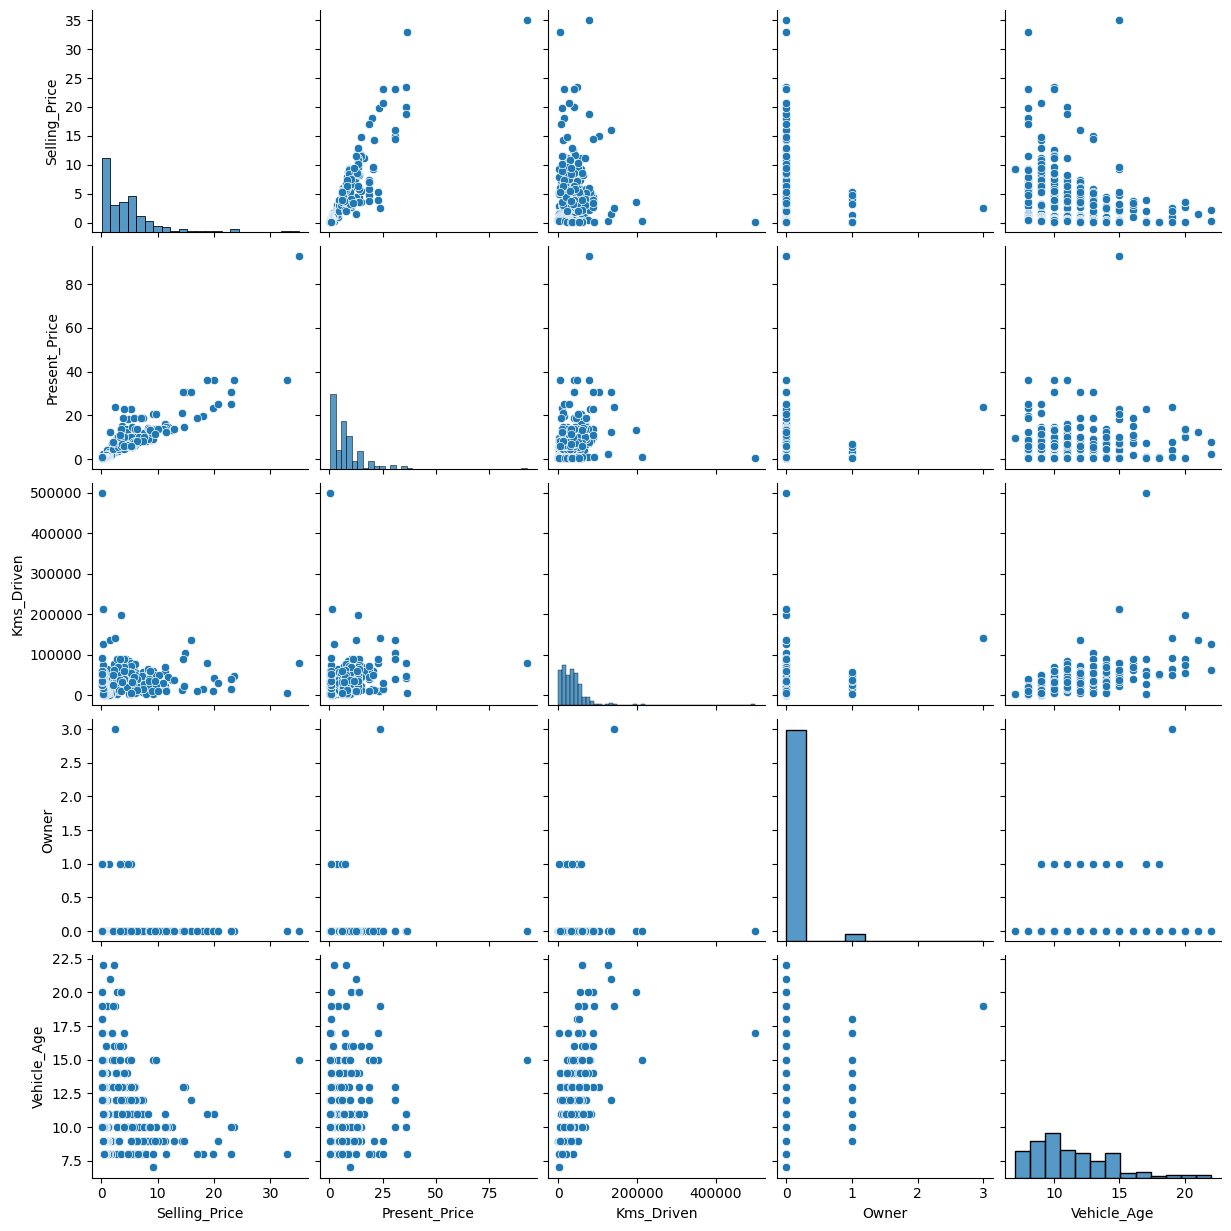

In [18]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, palette="Dark2");

In [19]:
import plotly.figure_factory as ff

fig = ff.create_distplot([df['Selling_Price']], ['Selling Price'],
                         show_hist=True,
                         show_rug=True)

fig.update_layout(
    title_text='Distribution and Box Plot of Selling Prices',  
    title_font_size=20,  
    xaxis_title_text='Selling Price',  
    yaxis_title_text='Density',  # Y eksen başlığı
    template='plotly_white',  # Arka planı beyaz yapıyoruz
    width=1000,  # Grafiğin genişliği
    height=500,  # Grafiğin yüksekliği
    bargap=0.01,  # Barlar arası boşluk
)

fig.show()

# Tree-based models are very robust against outliers. However, this is not the case for small regression datasets. 
# In small regression datasets, outlier values can significantly increase or decrease the average prices in the 
# leaves they fall into, making it important to remove these outlier observations that are insufficient for training 
# in tree-based models. However, as always, we should compare the scores both with and without outliers to see the 
# differences.

# The show_rug parameter displays the positions of data points on the x-axis with small lines. 
# This is useful for seeing the distribution and density of each observation in more detail.

# A rug plot is located under histogram or kernel density estimate (KDE) graphs. Small vertical lines representing 
# each data point show where values are concentrated in the dataset and potentially where outliers are located. 
# This feature is useful for understanding the distribution of the dataset because rug plots clearly show 
# the clustering areas and rare regions of data points.

In [20]:
import plotly.graph_objs as go

box_plot = go.Box(y=df['Selling_Price'], name='Selling Price')

fig = go.Figure(data=[box_plot])
fig.update_layout(title='Selling Price Box Plot')
fig.show()

* There are some **outlier**, bur we will not drop them at the moment, since we have a little observation. 

# Modelling

## Train | Test Split

In [21]:
X = df.drop("Selling_Price", axis=1)
y = df.Selling_Price

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=101)

print("Train features shape : ", X_train.shape)
print("Train target shape   : ", y_train.shape)
print("Test features shape  : ", X_test.shape)
print("Test target shape    : ", y_test.shape)

Train features shape :  (240, 7)
Train target shape   :  (240,)
Test features shape  :  (61, 7)
Test target shape    :  (61,)


## Modelling with Pipeline & ColumnTransformer

In [24]:
cat = X_train.select_dtypes("object").columns
cat

Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

In [25]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
column_trans = make_column_transformer((ord_enc, cat), remainder='passthrough')

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('DT_model', DecisionTreeRegressor(random_state=101))])

In [27]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [28]:
def train_val(model, X_train, y_train, X_test, y_test):

    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    scores = {
        "train": {
            "R2": r2_score(y_train, y_train_pred),
            "mae": mean_absolute_error(y_train, y_train_pred),
            "mse": mean_squared_error(y_train, y_train_pred),
            "rmse": np.sqrt(mean_squared_error(y_train, y_train_pred))
        },
        "test": {
            "R2": r2_score(y_test, y_pred),
            "mae": mean_absolute_error(y_test, y_pred),
            "mse": mean_squared_error(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
        }
    }

    return pd.DataFrame(scores)

In [29]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

# We have gained insight that overfitting is occurring. We will make our final decision in cross-validation (CV)

,train,test
R2,1.000,0.933
mae,0.000,0.512
mse,0.000,0.646
rmse,0.000,0.804


In [30]:
# CV

from sklearn.model_selection import cross_validate, cross_val_score

operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]
model = Pipeline(steps=operations)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores)
df_scores.mean()[2:]

# We confirmed that there was overfitting

test_r2                              0.872
train_r2                             1.000
test_neg_mean_absolute_error        -0.828
train_neg_mean_absolute_error        0.000
test_neg_mean_squared_error         -4.450
train_neg_mean_squared_error         0.000
test_neg_root_mean_squared_error    -1.665
train_neg_root_mean_squared_error    0.000
dtype: float64

## Outlier handling to improve scores

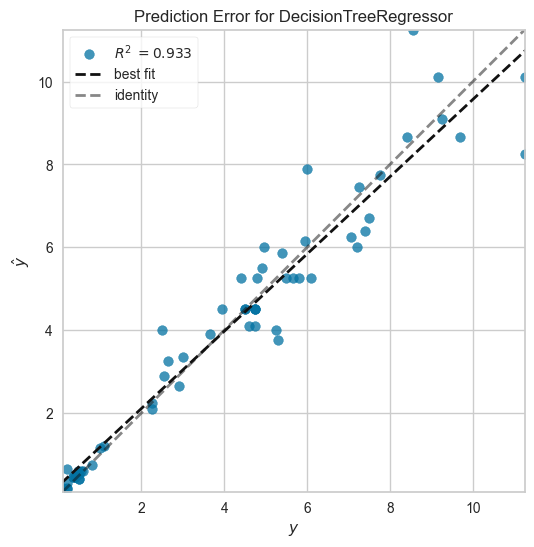

In [31]:
from yellowbrick.regressor import PredictionError
from yellowbrick.features import RadViz

visualizer = RadViz(size=(720, 600))

model = pipe_model
visualizer = PredictionError(model)
visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show();

# We observed that prices greater than 10 are distorting the predictions

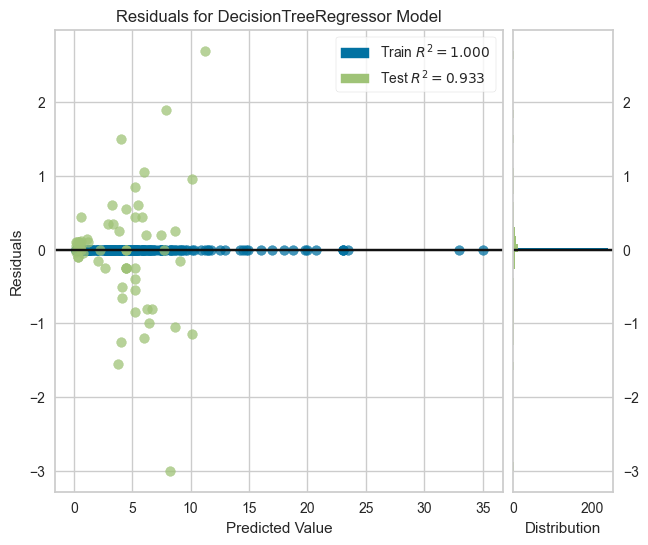

In [32]:
from yellowbrick.regressor import ResidualsPlot

visualizer = RadViz(size=(720, 600))
model = pipe_model
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show();

In [33]:
print(len(df[df.Selling_Price > 10]))

28


In [34]:
print(28 / 301)

# There are 28 observations over 10 in the data. Since their ratio to the entire dataset is 9%, I am dropping them

0.09302325581395349


In [35]:
# Filtering like drop the outliers 
df2 = df[df.Selling_Price < 10]
df2.head()

# filtered out the prices lower than 10

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,3.350,5.590,27000,Petrol,Dealer,Manual,0,11
1,4.750,9.540,43000,Diesel,Dealer,Manual,0,12
2,7.250,9.850,6900,Petrol,Dealer,Manual,0,8
3,2.850,4.150,5200,Petrol,Dealer,Manual,0,14
4,4.600,6.870,42450,Diesel,Dealer,Manual,0,11


In [36]:
df2.Selling_Price.max()

9.7

In [37]:
# Labelleing again
X = df2.drop(columns="Selling_Price")
y = df2.Selling_Price

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=101)

In [39]:
operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('DT_model', DecisionTreeRegressor(random_state=101))])

In [40]:
train_val(pipe_model, X_train, y_train, X_test, y_test)

# After the filtering process, the scores of our test data improved further, but the overfitting was still not eliminated.

,train,test
R2,1.000,0.935
mae,0.000,0.493
mse,0.000,0.533
rmse,0.000,0.730


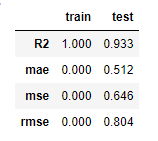

In [41]:
# CV

from sklearn.model_selection import cross_validate, cross_val_score

operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]
model = Pipeline(steps=operations)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores)
df_scores.mean()[2:]

# We confirmed that there was overfitting

test_r2                              0.892
train_r2                             1.000
test_neg_mean_absolute_error        -0.534
train_neg_mean_absolute_error        0.000
test_neg_mean_squared_error         -0.701
train_neg_mean_squared_error         0.000
test_neg_root_mean_squared_error    -0.814
train_neg_root_mean_squared_error    0.000
dtype: float64

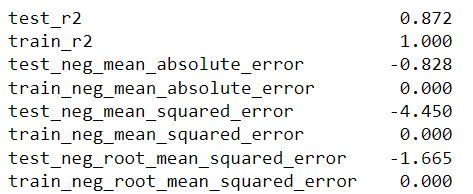

* Even though decrease, we have an overfitting problem still.  

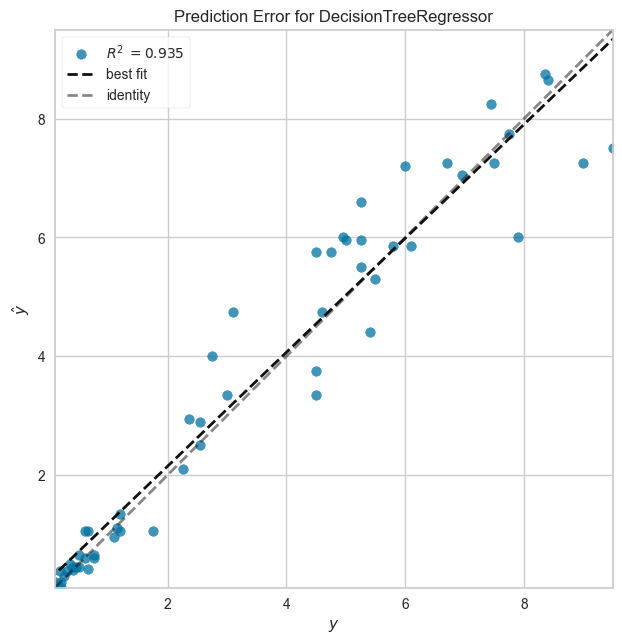

In [42]:
visualizer = RadViz(size=(720, 3000))

model = pipe_model
visualizer = PredictionError(model)
visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show();

# We can see here that the scores improved after filtering

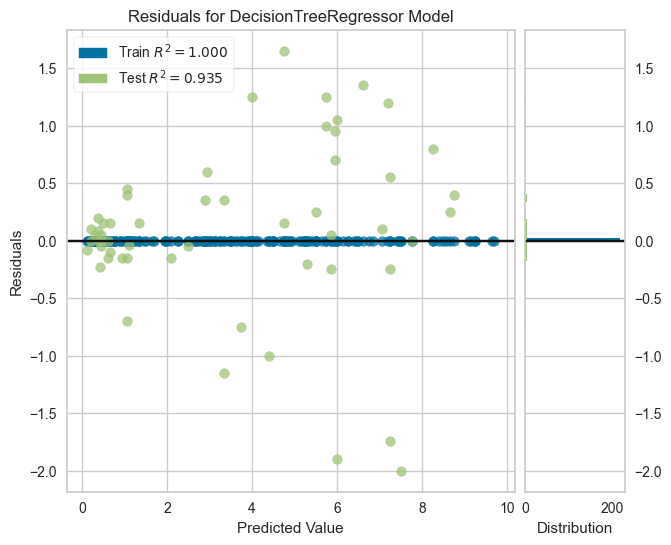

In [43]:
from yellowbrick.regressor import ResidualsPlot

visualizer = RadViz(size=(720, 600))
model = pipe_model
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show();

## Overfitting Risk and Features Importance

**Overfitting Analysis in Decision Tree Models**

**Examination of Model Performance on Training Data**

- **Observation**: If a decision tree model shows nearly or completely error-free performance on the training dataset, it may indicate that the model is prone to overfitting to the training data.
- **Analysis**: The analysis of high performance on the training set reveals that the model risks capturing details while missing essential patterns.

**Evaluation of Cross-Validation Results**

- **Observation**: If the model's cross-validation scores are significantly lower than the scores obtained on the training set, it indicates a **weak generalization ability = overfitting problem**.
- **Analysis**: Cross-validation is a reliable method to evaluate the model's performance on different data subsets. **If cross-validation scores of test are lower than training scores, it is considered a sign of overfitting**.

**Suggestions for Mitigating Overfitting**

- **Hyperparameter Tuning**: It may be necessary to adjust hyperparameters to **reduce model complexity and improve generalization ability**. Techniques such as limiting the depth of the decision tree and pruning can be used.

**Variance - Bias Trade-Off**

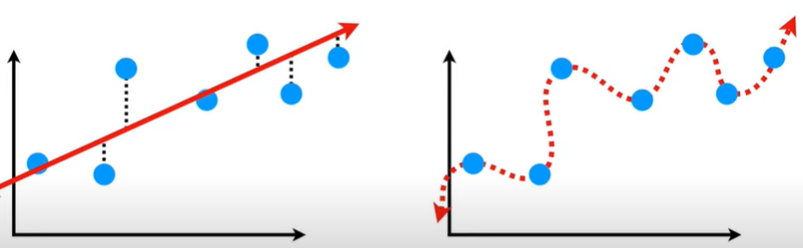


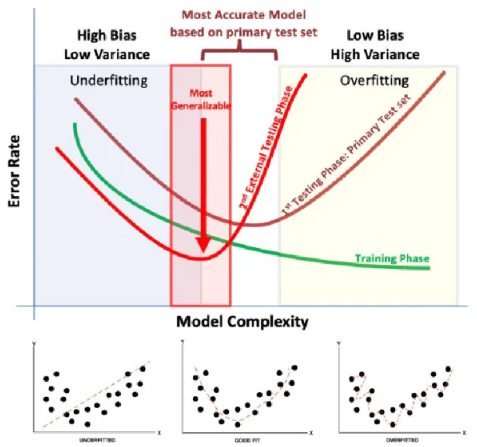

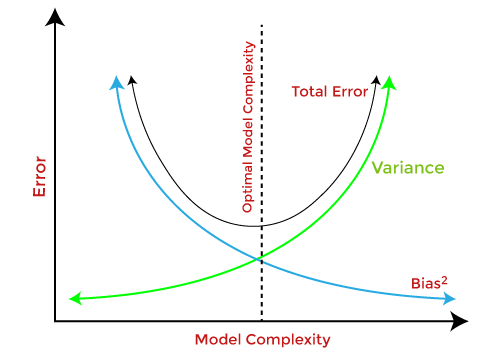

- **Expanding the Dataset**: Increasing the **amount of data** used for training can **enhance the model's generalization capacity**. This allows the model to see more diverse examples and learn stronger patterns.
- **Feature Engineering**: Removing unnecessary or misleading features that may affect the model's generalization performance and selecting and transforming important features can also be beneficial.

In [44]:
# After outliers dropped
operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]
pipe_model = Pipeline(steps=operations)
pipe_model.fit(X_train, y_train)

scores = cross_validate(pipe_model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)

df_scores = pd.DataFrame(scores)
df_scores.mean()[2:]

test_r2                              0.892
train_r2                             1.000
test_neg_mean_absolute_error        -0.534
train_neg_mean_absolute_error        0.000
test_neg_mean_squared_error         -0.701
train_neg_mean_squared_error         0.000
test_neg_root_mean_squared_error    -0.814
train_neg_root_mean_squared_error    0.000
dtype: float64

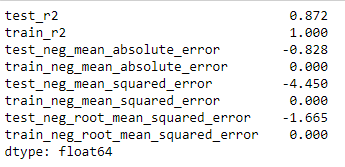

* Scores a little bit improved. 

In [45]:
# Feature Importance
pipe_model["DT_model"].feature_importances_

array([8.72315324e-03, 9.97470116e-04, 1.82731815e-03, 8.39118154e-01,
       2.14765459e-02, 1.55162018e-05, 1.27841843e-01])

In [46]:
features = pipe_model["OrdinalEncoder"].get_feature_names_out()
features

array(['ordinalencoder__Fuel_Type', 'ordinalencoder__Seller_Type',
       'ordinalencoder__Transmission', 'remainder__Present_Price',
       'remainder__Kms_Driven', 'remainder__Owner',
       'remainder__Vehicle_Age'], dtype=object)

In [47]:
new_features = [i.replace("ordinalencoder__", "").replace("remainder__", "") for i in features]
new_features

# We are getting rid of the ordinalencoder__ and remainder__ prefixes.

['Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Present_Price',
 'Kms_Driven',
 'Owner',
 'Vehicle_Age']

In [48]:
df_fi = pd.DataFrame(
    data=pipe_model["DT_model"].feature_importances_,
    index=new_features,  #index=X.columns
    columns=["Feature Importance"])
df_fi = df_fi.sort_values("Feature Importance", ascending=False)

df_fi

# We defined the dataframe showing feature importance ratios as df_fi. 

# Within df, we assign the feature importance ratios using pipe_model["DT_model"].feature_importances_, 
# and the feature names (new_features) that change order after make_column_transform to the index.
# Then, we sort the feature importance values from largest to smallest.

,Feature Importance
Present_Price,0.839
Vehicle_Age,0.128
Kms_Driven,0.021
Fuel_Type,0.009
Transmission,0.002
Seller_Type,0.001
Owner,0.000


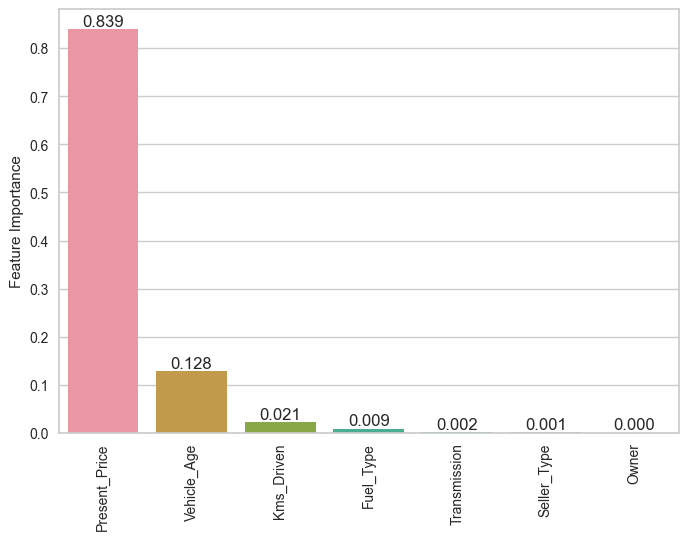

In [49]:
ax = sns.barplot(x=df_fi.index, y='Feature Importance', data=df_fi)
ax.bar_label(ax.containers[0], fmt="%.3f")
plt.xticks(rotation=90)
plt.show()

# We visualize the feature importance values with a bar plot. 
# We perform feature selection based on the ranking here.

* Model got 83.9% insight from "Present Price", and ignored owner etc.

* If we drop "Present Price" feature, model may get more insight from other features. 

**Feature Importance and Limitations in Decision Tree Models**

**Limitations and Examination of Feature Importance**

- **Limitation and Importance Ranking**: In decision trees, feature importance is usually based on how often a feature is used in the tree and the average information gain it provides at leaf nodes. However, this may not accurately reflect the absolute contribution of each feature to the model's predictions.
- **Analysis Methods**: Removing a feature from the model and reassessing the model's performance can be used to better understand the impact of that feature on the model. **If removing a feature causes a significant drop in model performance, it can be concluded that this feature is important for the model**.

**Application Example and Evaluation**

- **Experiment Design**: The effect of removing a feature from the model can be observed on the model's accuracy score or other performance metrics. If performance decreases when the feature is removed, it is understood that this feature is important for the model.
- **Interpretation of Results**: If removing a feature with high feature importance significantly affects the model's performance, it is concluded that this feature is genuinely important for the model.
- **Decision Making**: If a meaningful decrease in model accuracy is observed, it may be appropriate to retain this feature within the model. This helps preserve the overall performance of the model.

In [50]:
# Drop "Present_Price" feature. 
X2 = X.drop(columns=["Present_Price"])

# We assign the dataset to X2 after dropping the most important feature.

In [51]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,
                                                        y,
                                                        test_size=0.2,
                                                        random_state=101)

# We are creating the train and test datasets from the X2 data.

In [52]:
operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]

pipe_model2 = Pipeline(steps=operations)

pipe_model2.fit(X_train2, y_train2)

# We repeat the steps we performed above.

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('DT_model', DecisionTreeRegressor(random_state=101))])

In [53]:
y_pred = pipe_model2.predict(X_test2)
y_train_pred = pipe_model2.predict(X_train2)

In [54]:
train_val(pipe_model2, X_train2, y_train2, X_test2, y_test2)

,train,test
R2,0.998,0.706
mae,0.013,1.008
mse,0.010,2.404
rmse,0.102,1.550


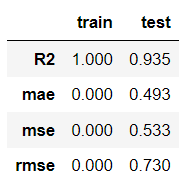

In [55]:
operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]

model = Pipeline(steps=operations)

scores = cross_validate(model,
                        X_train2,
                        y_train2,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)
df2_scores = pd.DataFrame(scores)
df2_scores.mean()[2:]

test_r2                              0.193
train_r2                             0.999
test_neg_mean_absolute_error        -1.564
train_neg_mean_absolute_error       -0.011
test_neg_mean_squared_error         -5.214
train_neg_mean_squared_error        -0.009
test_neg_root_mean_squared_error    -2.246
train_neg_root_mean_squared_error   -0.092
dtype: float64

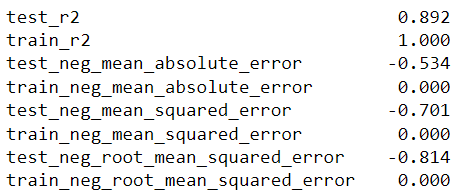

* Scores didn't improve when we drop the best parameter. Its' mean "**Present_Price**" is very **important feature** for our odel and we **shouldn't drop** it.   

In [56]:
# Feture Importance
decision_tree_model = pipe_model2.named_steps["DT_model"]

feature_importances = decision_tree_model.feature_importances_

df2_fi = pd.DataFrame(data=feature_importances,
                      index=X_train2.columns,
                      columns=["Feature Importance"])

df2_fi = df2_fi.sort_values(by="Feature Importance", ascending=False)

df2_fi

,Feature Importance
Fuel_Type,0.607
Transmission,0.185
Vehicle_Age,0.152
Kms_Driven,0.035
Seller_Type,0.017
Owner,0.004


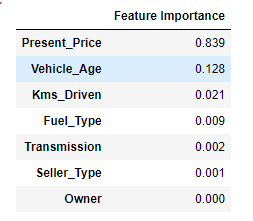

* When we drop the "Present Price", DT **got more insight** from Transmission, Seller Type and Owner.  

* But it didn't improve our model scores. 

## Visualizing Trees

**Splitting Process in Decision Tree Regression**

- **Statistical Approach**: The splitting process in regression trees requires rigorous statistical analysis to determine optimal split points for continuous variables. This analysis evaluates the potential for variance reduction at each potential split point.

- **Splitting Criterion**: The criterion used in the splitting process is typically a metric like Minimum Variance Reduction (MVR) or Mean Squared Error Reduction (MSER). These metrics ensure that the dataset is divided into homogeneous subgroups, helping the values within each group to show a tighter distribution around the mean.

- **Optimization**: The splitting process groups continuous values in the dataset to **minimize variance**. The average of the data points within these groups is used as the predicted value for observations falling into that group. This makes the model's predictions more aligned with the actual distribution of the dataset.

- **Model Behavior**: The regression tree applies a continuous splitting process on continuous variables and makes predictions using the average of each subgroup. This methodology allows the model to effectively capture variations and patterns in the training dataset and improve its predictions on new data.

**Effectiveness and Complexity**

- **Size of the Tree**: ! Regression trees typically have **more nodes** and **branches** compared to classification trees because the **split points for continuous variables can be more numerous and detailed**. This may **increase the model's complexity** and pose a **risk of overfitting**.


- **Pruning Strategies**: Pruning strategies are employed to manage this complexity. Pruning helps prevent excessive complexity while maintaining the model's ability to generalize. It helps reduce generalization error by preventing the model from becoming prone to overfitting.

In [57]:
from sklearn.tree import plot_tree

In [58]:
X = df2.drop(columns="Selling_Price")
y = df2.Selling_Price

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=101)

In [60]:
operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X_train, y_train)

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('DT_model', DecisionTreeRegressor(random_state=101))])

In [61]:
features = pipe_model["OrdinalEncoder"].get_feature_names_out()
features

# Since the make_column_transform function is used within the pipeline, we must remember that the feature order changes.

array(['ordinalencoder__Fuel_Type', 'ordinalencoder__Seller_Type',
       'ordinalencoder__Transmission', 'remainder__Present_Price',
       'remainder__Kms_Driven', 'remainder__Owner',
       'remainder__Vehicle_Age'], dtype=object)

In [62]:
new_features = [i.replace("ordinalencoder__", "").replace("remainder__", "") for i in features]
new_features

# We are getting rid of the ordinalencoder__ and remainder__ prefixes.

['Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Present_Price',
 'Kms_Driven',
 'Owner',
 'Vehicle_Age']

In [63]:
pd.DataFrame(pipe_model["OrdinalEncoder"].fit_transform(X_train),
             columns=new_features)

# The final state of the dataframe after the structure is changed by make_column_transform. 
# As you can see, the categorical features have come first, followed by the numeric features.

,Fuel_Type,Seller_Type,Transmission,Present_Price,Kms_Driven,Owner,Vehicle_Age
0,2.000,1.000,1.000,0.540,14000.000,0.000,9.000
1,2.000,0.000,1.000,4.600,22517.000,0.000,14.000
2,2.000,0.000,1.000,5.900,9800.000,0.000,12.000
3,1.000,0.000,1.000,9.400,49000.000,0.000,12.000
4,2.000,0.000,1.000,18.610,72000.000,0.000,13.000
5,2.000,1.000,1.000,0.870,15000.000,0.000,9.000
6,2.000,0.000,1.000,7.600,50456.000,0.000,19.000
7,2.000,0.000,1.000,6.760,40000.000,0.000,11.000
8,2.000,1.000,1.000,2.400,7000.000,0.000,11.000
9,2.000,1.000,1.000,2.280,127000.000,0.000,22.000


In [64]:
X_train.head(1)

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
164,0.540,14000,Petrol,Individual,Manual,0,9


[Text(0.4974557976973684, 0.9615384615384616, 'Present_Price <= 5.47\nsquared_error = 6.898\nsamples = 218\nvalue = 3.391'),
 Text(0.29704632675438597, 0.8846153846153846, 'Present_Price <= 3.455\nsquared_error = 0.964\nsamples = 101\nvalue = 1.102'),
 Text(0.3972510622258772, 0.9230769230769231, 'True  '),
 Text(0.2031935307017544, 0.8076923076923077, 'Present_Price <= 1.11\nsquared_error = 0.148\nsamples = 80\nvalue = 0.651'),
 Text(0.12513706140350878, 0.7307692307692307, 'Vehicle_Age <= 11.5\nsquared_error = 0.032\nsamples = 57\nvalue = 0.445'),
 Text(0.0556469298245614, 0.6538461538461539, 'Present_Price <= 0.73\nsquared_error = 0.021\nsamples = 31\nvalue = 0.551'),
 Text(0.02850877192982456, 0.5769230769230769, 'Kms_Driven <= 34800.0\nsquared_error = 0.003\nsamples = 12\nvalue = 0.427'),
 Text(0.017543859649122806, 0.5, 'Vehicle_Age <= 9.5\nsquared_error = 0.002\nsamples = 10\nvalue = 0.444'),
 Text(0.008771929824561403, 0.4230769230769231, 'Kms_Driven <= 4150.0\nsquared_error = 

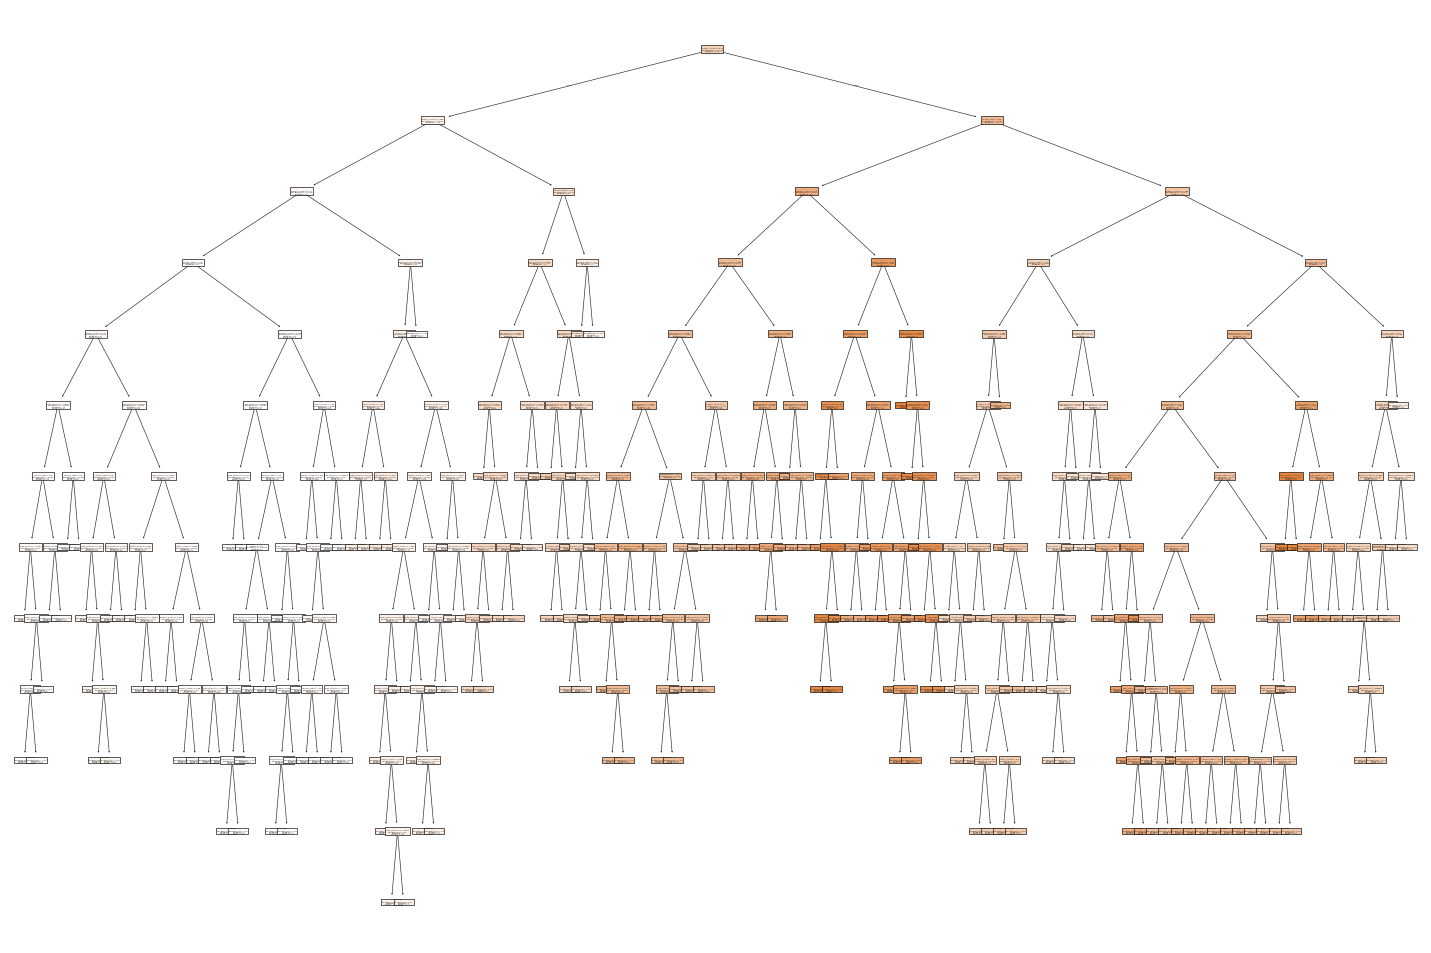

In [65]:
plt.figure(figsize=(12, 8), dpi=150)
plot_tree(pipe_model["DT_model"], filled=True, feature_names=new_features)
#feature_names=X.columns

# In regression problems, tree-based models tend to have significantly more branches compared to classification problems.

In [66]:
def report_model(model):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    print('\n')
    print(train_val(model, X_train, y_train, X_test, y_test))
    print('\n')
    plt.figure(figsize=(12, 8), dpi=100)
    plot_tree(model["DT_model"],
              filled=True,
              feature_names=new_features,
              fontsize=8)
    #feature_names=X.columns


# With this function, we compare the scores of the train and test sets and visualize our tree.



      train  test
R2    0.873 0.928
mae   0.591 0.524
mse   0.874 0.589
rmse  0.935 0.768




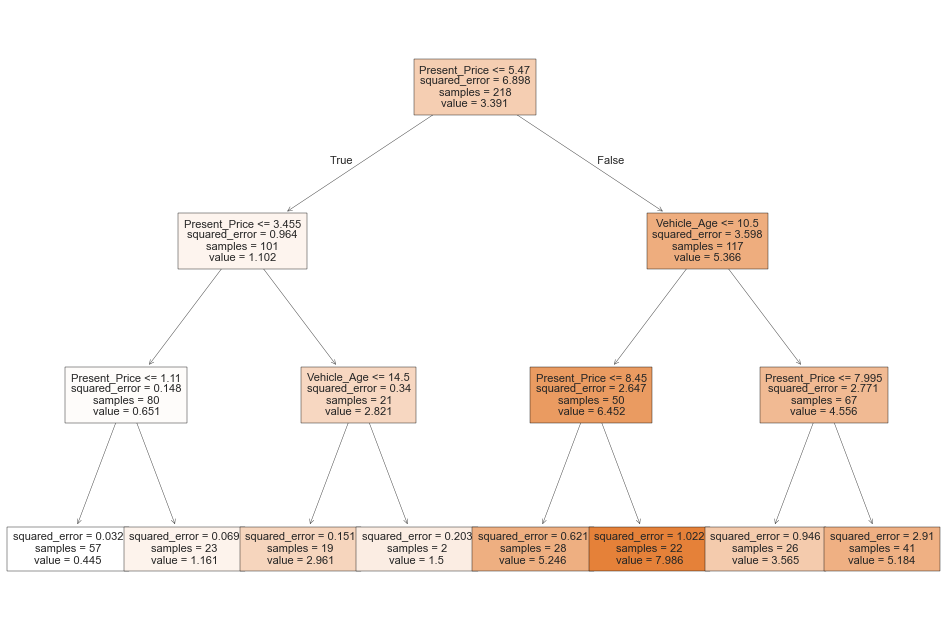

In [67]:
operations = [("OrdinalEncoder", column_trans),
              ("DT_model",
               DecisionTreeRegressor(criterion='squared_error',
                                     max_depth=3,  # we restricted depth (reduced model complexity)
                                     random_state=101))]

pruned_tree = Pipeline(steps=operations)
pruned_tree.fit(X_train, y_train)

report_model(pruned_tree)

#  The only difference from classification is that the criterion is set to 'squared_error'. 
# In classification, this hyperparameter is either 'gini' or 'entropy'. 
# In regression, the criterion can be one of 'squared_error', 'friedman_mse', 'absolute_error', or 'poisson'. 
# However, the model usually performs best with 'squared_error', which is the default value. 
# Squared error represents the mean squared error. An error of 0 in a leaf indicates that all cars falling 
# into that leaf have the same price, while a value close to 0 indicates that the cars have very similar prices. 
# A high error value suggests that cars with very different prices fall into that leaf.

# samples: Shows the total number of observations in the respective leaf.
# value: Indicates the average price of the observations in the respective leaf.
# When a predicted observation falls into a specific leaf, the value in that leaf becomes the value predicted 
# by the model for the car.

**NOTE: The weighted average of the variance of the groups created at each split is subtracted from the variance before the split. The split point with the highest variance reduction becomes the new node.**

**Question 1:** Which cars located at the first leaf node? 

In [68]:
# Answer 1
indexes = X_train[X_train.Present_Price <= 1.11].index
df.iloc[indexes]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
164,0.450,0.540,14000,Petrol,Individual,Manual,0,9
138,0.600,0.870,15000,Petrol,Individual,Manual,0,9
128,0.800,0.870,3000,Petrol,Individual,Manual,0,8
134,0.650,0.810,11800,Petrol,Individual,Manual,0,8
152,0.500,0.990,13000,Petrol,Individual,Manual,0,13
175,0.380,0.787,75000,Petrol,Individual,Manual,0,14
194,0.200,0.787,50000,Petrol,Individual,Manual,0,17
179,0.310,1.050,213000,Petrol,Individual,Manual,0,15
198,0.150,0.570,35000,Petrol,Individual,Manual,1,14
191,0.200,0.570,25000,Petrol,Individual,Manual,1,13


In [69]:
len(df.iloc[indexes])

57

**Question 2:**  Which cars located at the second leaf node?

In [70]:
# Answer 2
indexes = X_train[(X_train.Present_Price <= 3.455) & (X_train.Present_Price >1.11) ].index
df.iloc[indexes]

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
112,1.150,2.400,7000,Petrol,Individual,Manual,0,11
37,0.350,2.280,127000,Petrol,Individual,Manual,0,22
107,1.250,1.500,15000,Petrol,Individual,Manual,0,12
108,1.200,1.500,18000,Petrol,Individual,Manual,0,9
123,1.000,1.470,46500,Petrol,Individual,Manual,0,12
104,1.350,1.470,4100,Petrol,Individual,Manual,0,8
115,1.110,1.470,17500,Petrol,Individual,Manual,0,10
121,1.050,1.500,6900,Petrol,Individual,Manual,0,14
119,1.050,1.900,5400,Petrol,Individual,Manual,0,12
113,1.150,1.400,35000,Petrol,Individual,Manual,0,9


In [71]:
len(df.iloc[indexes])

23

## Hyperparmeter Tuning via Grid Search

**criterion**

1. **squared_error**:
   - This is the mean squared error (MSE) criterion used to evaluate the quality of a split.
   - At each node, it finds the best split by trying to minimize the mean squared error.
   - This is usually the default criterion and allows the tree to reduce the variance of the target variable.

2. **friedman_mse**:
   - This criterion is an improved squared error measure developed by the famous statistician Jerome Friedman.
   - 'friedman_mse' is often used with gradient boosting trees and includes an additional correction term to improve tree splits.
   - This criterion is used especially to enhance the performance of gradient boosting models.

3. **absolute_error**:
   - This criterion uses the mean absolute error (MAE) to determine the quality of a split.
   - It is a preferred criterion to reduce the impact of outliers as it considers absolute differences rather than squared differences.
   - It can be more costly to compute since the derivative of the absolute value function is not defined at every point.

4. **poisson**:
   - This criterion is suitable for cases where regression targets follow a Poisson distribution, such as count data or event rates.
   - Poisson loss is used to evaluate the quality of predictions on actual counts of a target variable.
   - Poisson regression is especially used when the target variable is a count (e.g., the number of events occurring within a time interval) and the variance of the error terms is proportional to the mean values.

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
operations = [("OrdinalEncoder", column_trans),
              ("DT_model", DecisionTreeRegressor(random_state=101))]

pipe_model = Pipeline(steps=operations)

In [74]:
param_grid = {
    "DT_model__splitter": ["best", "random"],
    "DT_model__criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "DT_model__max_depth": [2, 3,],
    "DT_model__min_samples_leaf": [1, 2, 3],
    "DT_model__min_samples_split": [2, 3],
    "DT_model__max_features": [4, 5, None]
}

In [75]:
grid_model = GridSearchCV(estimator=pipe_model,
                          param_grid=param_grid,
                          scoring='neg_root_mean_squared_error',
                          cv=10,
                          n_jobs=-1,
                          return_train_score=True)

In [76]:
grid_model.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('OrdinalEncoder',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinalencoder',
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                                       ('DT_model',
                                        DecisionTreeRegressor(random_state=101))]),
             n_jobs=-1,
             param_grid={'DT_model__criterion': ['squared_error',
                                                 'friedman_mse',
                                                 'absolute_error'],
                         'DT_model__max_depth': [2, 3],
                         'DT_model__max_features': [4, 5, None],
                         'DT_model__min_samples_leaf': [1, 2, 3],
                         'DT_model__min_samples_split': [2, 3],
                         'DT_model__splitter': ['best', 'random']},
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [77]:
grid_model.best_estimator_  

Pipeline(steps=[('OrdinalEncoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('DT_model',
                 DecisionTreeRegressor(criterion='absolute_error', max_depth=3,
                                       random_state=101))])

In [78]:
grid_model.best_params_  # It gives except default hyperparameters. 

{'DT_model__criterion': 'absolute_error',
 'DT_model__max_depth': 3,
 'DT_model__max_features': None,
 'DT_model__min_samples_leaf': 1,
 'DT_model__min_samples_split': 2,
 'DT_model__splitter': 'best'}

In [79]:
index = grid_model.best_index_
index

204

In [80]:
pd.DataFrame(
    grid_model.cv_results_).loc[index, ["mean_test_score", "mean_train_score"]]

mean_test_score    -1.074
mean_train_score   -0.975
Name: 204, dtype: object

In [81]:
grid_model.best_score_

-1.0740459549634755

In [82]:
train_val(grid_model, X_train, y_train, X_test, y_test)

# We observed that the test data scores are consistent with the validation set scores we obtained from CV.

,train,test
R2,0.861,0.877
mae,0.621,0.700
mse,0.957,1.010
rmse,0.978,1.005


In [83]:
# CV 
from sklearn.model_selection import cross_validate, cross_val_score

operations = [("OrdinalEncoder", column_trans),
              ("DT_model",
               DecisionTreeRegressor(criterion="absolute_error",
                                     max_depth=3,
                                     random_state=101))]

model = Pipeline(steps=operations)

scores = cross_validate(model,
                        X_train,
                        y_train,
                        scoring=[
                            'r2', 'neg_mean_absolute_error',
                            'neg_mean_squared_error',
                            'neg_root_mean_squared_error'
                        ],
                        cv=10,
                        return_train_score=True)
df_scores = pd.DataFrame(scores, index=range(1, 11))
df_scores.iloc[:, 2:]

# We can use CV to see all metrics. When we look at all the iterations in CV, we can see that some scores 
# are very different. This is an expected situation in very small datasets.

,test_r2,train_r2,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_neg_mean_squared_error,train_neg_mean_squared_error,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
1,0.805,0.861,-0.914,-0.600,-1.307,-0.959,-1.143,-0.979
2,0.510,0.891,-1.140,-0.553,-2.474,-0.768,-1.573,-0.876
3,0.885,0.859,-0.565,-0.631,-0.548,-1.002,-0.741,-1.001
4,0.811,0.869,-0.782,-0.590,-1.340,-0.887,-1.157,-0.942
5,0.892,0.838,-0.607,-0.639,-0.780,-1.107,-0.883,-1.052
6,0.850,0.845,-0.750,-0.618,-1.189,-1.052,-1.090,-1.026
7,0.766,0.860,-0.715,-0.627,-2.040,-0.937,-1.428,-0.968
8,0.899,0.865,-0.441,-0.628,-0.535,-0.952,-0.731,-0.976
9,0.813,0.865,-0.832,-0.602,-1.185,-0.938,-1.089,-0.968
10,0.894,0.863,-0.713,-0.605,-0.818,-0.932,-0.904,-0.966


In [84]:
df_scores.mean()[2:]

# based on the averages

test_r2                              0.813
train_r2                             0.862
test_neg_mean_absolute_error        -0.746
train_neg_mean_absolute_error       -0.609
test_neg_mean_squared_error         -1.222
train_neg_mean_squared_error        -0.953
test_neg_root_mean_squared_error    -1.074
train_neg_root_mean_squared_error   -0.975
dtype: float64

In [85]:
train_val(grid_model, X_train, y_train, X_test, y_test)

,train,test
R2,0.861,0.877
mae,0.621,0.700
mse,0.957,1.010
rmse,0.978,1.005


* Scores close to each other, we **solved the overfitting** problem. 

# Compare real and predicted result

In [86]:
y_pred = grid_model.predict(X_test)
my_dict = { 'Actual': y_test, 'Pred': y_pred, 'Residual': y_test-y_pred }
compare = pd.DataFrame(my_dict)

# We compare the actual and predicted values with the residuals to see whether the model's predictions are successful.

In [87]:
comp_sample = compare.sample(20)
comp_sample

,Actual,Pred,Residual
33,6.000,6.950,-0.950
100,1.750,1.150,0.600
60,6.950,6.950,0.000
254,5.250,6.950,-1.700
166,0.450,0.510,-0.060
153,0.500,0.285,0.215
81,4.750,6.950,-2.200
110,1.200,1.150,0.050
41,2.550,2.850,-0.300
137,0.650,0.285,0.365


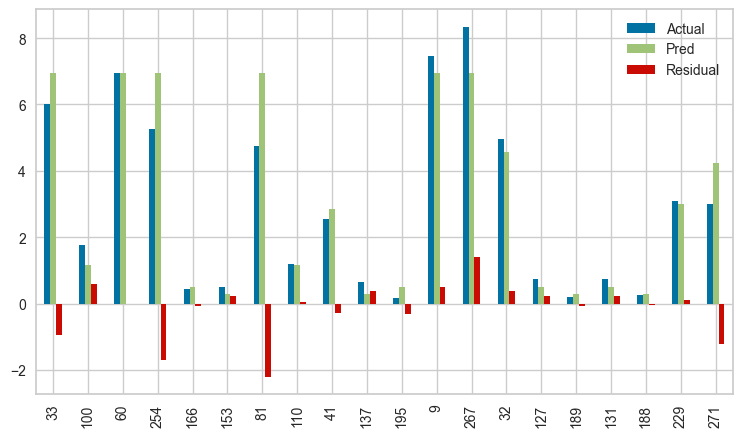

In [88]:
comp_sample.plot(kind='bar',figsize=(9,5))
plt.show()

# Final Model & Prediction

We obtain final model using **all data** and **best hyperparameters**.

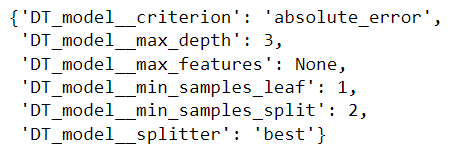

In [89]:
X=df2.drop("Selling_Price", axis=1)
y=df2.Selling_Price

In [90]:
X.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,5.590,27000,Petrol,Dealer,Manual,0,11
1,9.540,43000,Diesel,Dealer,Manual,0,12
2,9.850,6900,Petrol,Dealer,Manual,0,8
3,4.150,5200,Petrol,Dealer,Manual,0,14
4,6.870,42450,Diesel,Dealer,Manual,0,11


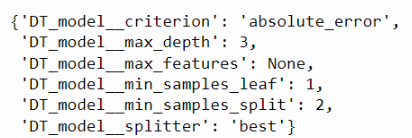

In [91]:
from sklearn.pipeline import Pipeline

operations = [("Ordinalcoder", column_trans),
              ("DT_model",
               DecisionTreeRegressor(criterion="absolute_error",
                                     max_depth=3,
                                     random_state=101))]

pipe_model = Pipeline(steps=operations)

pipe_model.fit(X, y)

# We rebuild our final model for all the data with the best hyperparameters.

Pipeline(steps=[('Ordinalcoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('DT_model',
                 DecisionTreeRegressor(criterion='absolute_error', max_depth=3,
                                       random_state=101))])

## Save the Final Model

In [92]:
import joblib

joblib.dump(pipe_model, 'Final_DT_Regression_Model.joblib')

['Final_DT_Regression_Model.joblib']

# Done. TASK completed....

# Get Prediction on a New Data

In [93]:
loaded_model = joblib.load('Final_DT_Regression_Model.joblib')

In [94]:
X.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,5.590,27000,Petrol,Dealer,Manual,0,11
1,9.540,43000,Diesel,Dealer,Manual,0,12
2,9.850,6900,Petrol,Dealer,Manual,0,8
3,4.150,5200,Petrol,Dealer,Manual,0,14
4,6.870,42450,Diesel,Dealer,Manual,0,11


In [95]:
X.describe()

,Present_Price,Kms_Driven,Owner,Vehicle_Age
count,273.000,273.000,273.000,273.000
mean,5.879,36516.941,0.048,11.527
std,4.955,39529.116,0.260,2.943
min,0.320,500.000,0.000,7.000
25%,0.990,15001.000,0.000,9.000
50%,5.700,32000.000,0.000,11.000
75%,8.920,48000.000,0.000,13.000
max,23.730,500000.000,3.000,22.000


In [96]:
samples = {"Present_Price": [6.5, 9],
           "Kms_Driven": [22000, 41000],
           "Fuel_Type":["Petrol", "Diesel"],
           'Seller_Type':['Dealer', 'Individual'],
           'Transmission': ['Manual', 'Automatic'],
           "Owner":[0,1],
           "Vehicle_Age":[2, 8]}

In [97]:
# Transfrom them to df
df_samples = pd.DataFrame(samples)
df_samples

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,6.500,22000,Petrol,Dealer,Manual,0,2
1,9.000,41000,Diesel,Individual,Automatic,1,8


In [98]:
loaded_model.predict(df_samples)

array([4.65, 6.9 ])

**Conclussion:** These cars sales prices should be USD 4.65K and USD 6.9K respectively. 